In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/retail_sales.csv')
# df.head()
display(df.shape)
display(df.info())

(3500, 38)

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         3500 non-null   str    
 1   order_date             3500 non-null   str    
 2   year                   3500 non-null   int64  
 3   month                  3500 non-null   int64  
 4   quarter                3500 non-null   str    
 5   store_id               3500 non-null   str    
 6   store_format           3500 non-null   str    
 7   region                 3500 non-null   str    
 8   sales_channel          3500 non-null   str    
 9   employee_id            3500 non-null   str    
 10  customer_id            3225 non-null   str    
 11  customer_segment       3500 non-null   str    
 12  category               3500 non-null   str    
 13  subcategory            3500 non-null   str    
 14  product_id             3500 non-null   str    
 15  supplier       

None

In [4]:
df.describe()

,year,month,base_price_php,unit_cost_php,discount_pct,selling_price_php,quantity_sold,gross_revenue_php,cogs_php,gross_profit_php,gross_margin_pct,shipping_cost_php,delivery_days,return_flag,stock_level,reorder_point,stockout_flag,customer_rating,nps_score,loyalty_points_earned,marketing_spend_php
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3252.000000,2250.000000,3500.000000,3500.000000
mean,2023.013714,6.478571,3079.743891,1843.615409,13.017143,2691.824051,4.461714,10528.003137,7186.734240,3341.268897,26.549426,130.689937,3.640571,0.116857,246.666286,49.540571,0.098571,3.786900,5.040889,119.616286,150.533606
std,0.821152,3.465891,3910.270620,2332.973470,18.523592,3630.562063,4.233533,20746.473808,13372.994806,8475.453750,23.613945,100.643999,3.524213,0.321296,143.968043,17.519590,0.298128,0.760713,3.159622,253.185815,188.455253
min,2022.000000,1.000000,28.990000,20.350000,0.000000,28.990000,1.000000,57.980000,40.700000,-25329.400000,-49.990000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,0.000000,0.000000,0.010000
25%,2022.000000,3.000000,954.472500,557.320000,0.000000,780.960000,2.000000,1740.085000,1243.125000,261.315000,19.632500,0.000000,0.000000,0.000000,123.000000,34.000000,0.000000,3.300000,2.000000,19.000000,31.372500
50%,2023.000000,6.000000,1868.615000,1104.795000,0.000000,1554.810000,3.000000,4372.815000,3092.710000,1118.705000,33.090000,131.520000,3.000000,0.000000,241.000000,50.000000,0.000000,3.800000,5.000000,48.000000,82.780000
75%,2024.000000,9.000000,3719.302500,2239.865000,25.000000,3217.322500,5.000000,10466.797500,7604.000000,3283.852500,42.830000,220.805000,5.000000,0.000000,373.250000,64.000000,0.000000,4.300000,8.000000,118.000000,195.830000
max,2024.000000,12.000000,61493.570000,35441.890000,50.000000,61493.570000,20.000000,368961.420000,212651.340000,183347.880000,55.000000,299.950000,14.000000,1.000000,500.000000,80.000000,1.000000,5.000000,10.000000,6696.000000,2319.740000


In [5]:
# df.isnull().sum()
null_cols = ['customer_id', 'promo_type',  'return_reason', 'customer_rating', 'nps_score']


**Q1. [Board Report]**
The CEO wants a single-slide revenue summary for the board. Compute total gross revenue, total gross profit, and average gross margin across all years. Then break these down by `year`. Has the business grown year-over-year? What is the YoY growth rate in revenue?

- first thing to do is to list down all necessary columns to extract whats needed. and make dataframe for the total gorss revenue,profit and gross margin percentage then group it by 'year'
- as for the output of year over year growth, there is NaN val as there is no year before 2022 so it doesnt have a year to compare it with, on 2023 the company have a decrease of 14.17% percent but made a growth revenue of 10.97% in 2024
- I would say the business is still good considering the gross percentage and revenuew growth in 2024. althoug  there are some loss in last years growth, there is a building momentum for the year 2024 that could boom the business

In [11]:
df_copy = df.copy()
money_cols = ['gross_revenue_php', 'gross_profit_php', 'gross_margin_pct', 'year']

df_copy[money_cols] = df_copy[money_cols].apply(pd.to_numeric, errors='coerce')
    
overall = pd.DataFrame({
    "total_gross_revenue": [df_copy['gross_revenue_php'].sum()],
    "total_gross_profit": [df_copy['gross_profit_php'].sum()],
    "average_gross_margin_pct": [df_copy['gross_margin_pct'].mean()],
})


# display(overall)


yearly = (df_copy.groupby('year', as_index=False).agg(total_gross_revenue=('gross_revenue_php', 'sum'),
                                                    total_gross_profit=('gross_profit_php', 'sum'),
                                                    average_gross_margin_pct=('gross_margin_pct', 'mean')).sort_values('year'))

yearly["yoy_revenue_growth_pct"] = (yearly["total_gross_revenue"].pct_change() * 100).round(2)
display(yearly)

,year,total_gross_revenue,total_gross_profit,average_gross_margin_pct,yoy_revenue_growth_pct
0,2022,13109425.93,4356478.24,26.811799,NaN
1,2023,11252044.14,3392608.96,25.923947,-14.17
2,2024,12486540.91,3945353.94,26.889743,10.97


**Q2. [Regional GM Request]**
Each regional general manager wants to know how their region is performing. Build a summary table of `region` showing: total transactions, total revenue, total profit, and average margin. Sort by total revenue descending. Which region is the top performer? Which is the weakest?

In [26]:
# df.describe()
# display(df.sample(5))
# print(money_cols)
# df_copy['region'].value_counts().plot(kind='barh', figsize=(8, 5))

region_summary = (df_copy.groupby('region', as_index=False).agg(total_transactions=('transaction_id', 'count'),
                                                                total_gross_revenue=('gross_revenue_php', 'sum'),
                                                                total_gross_profit=('gross_profit_php', 'sum'),
                                                                average_margin=('gross_margin_pct', 'mean')).sort_values('total_gross_revenue', ascending=False))


display(region_summary.round(2))

top_region = region_summary.iloc[0]['region']
weakest = region_summary.iloc[-1]['region']

print(f"Top performing region: {top_region}")
print(f"Weakest performing region: {weakest}")


,region,total_transactions,total_gross_revenue,total_gross_profit,average_margin
2,Cebu,448,5087137.42,1673124.47,27.74
3,Davao,451,4901141.38,1518528.50,27.28
7,Pampanga,457,4705213.25,1392355.55,26.67
5,Laguna,464,4638748.47,1520623.57,26.41
6,NCR,423,4534241.83,1356852.30,25.36
4,Iloilo,444,4489478.04,1477005.40,24.80
1,Cagayan de Oro,402,4433331.60,1428229.70,26.25
0,Batangas,411,4058718.99,1327721.65,27.87


Top performing region: Cebu
Weakest performing region: Batangas


**Q2. [Regional GM Request]**
Each regional general manager wants to know how their region is performing. Build a summary table of `region` showing: total transactions, total revenue, total profit, and average margin. Sort by total revenue descending. Which region is the top performer? Which is the weakest?
- at the region that has the highest gross reveneue and gross profit is the cebu region
- as for the lowest it is the batangas region however even though this has the lowest gross, it has the highest average margin percentage amonmg all the regions
- and the region who has the highest number of transactions is teh Laguna region with 464 total transactions

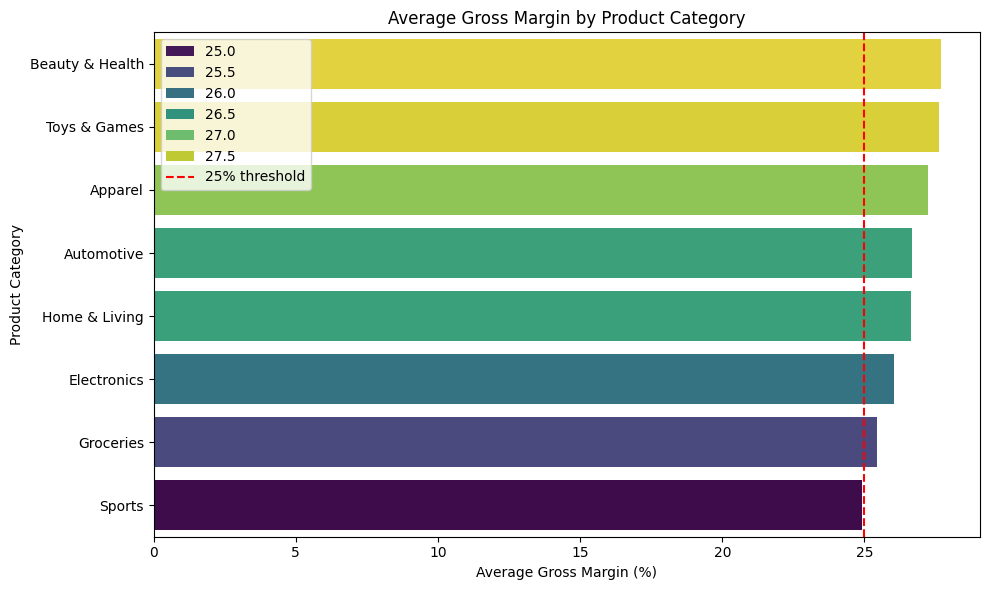

Categories with average gross margin below 25%:
['Sports']


,category,gross_margin_pct


In [55]:
df.sample(5)

df_copy['gross_margin_pct'] = pd.to_numeric(df_copy['gross_margin_pct'], errors='coerce')
threshold = 25

category_margin = (df_copy.groupby('category', as_index=False)['gross_margin_pct'].mean().sort_values('gross_margin_pct', ascending=False))

# display(category_margin.round(2))

plt.figure(figsize=(10,6))
sns.barplot(data=category_margin, x='gross_margin_pct', y='category', palette='viridis', hue='gross_margin_pct', dodge=False)
plt.axvline(threshold, color="red", linestyle="--", linewidth=1.5, label="25% threshold")
plt.xlabel('Average Gross Margin (%)')
plt.ylabel('Product Category')
plt.title('Average Gross Margin by Product Category')
plt.legend()
plt.tight_layout()
plt.savefig('../output/q3_average_gross_margin.png', bbox_inches='tight')
plt.show()


below_threshold = category_margin[category_margin['gross_margin_pct'] < threshold]
print("Categories with average gross margin below 25%:")
print(below_threshold['category'].tolist())

loss_average = category_margin[category_margin['gross_margin_pct'] < 0].copy()
loss_average['gross_margin_pct'] = loss_average['gross_margin_pct'].round(2)
display(loss_average)

**Q3. [CFO — Profitability Audit]**
The CFO suspects some product categories are dragging down overall margins. Plot gross margin (%) by `category` using a horizontal barplot, sorted from highest to lowest. Identify any category with a margin below 25%. Are there categories where the company might be selling at a loss?
- The only category that is falling behind the the threshold margin of 25% is the 'Sports' category, it is actually not that far from the threshold as we cann see on the graph its about a decimal off.
- although sports is falling behind the trehshold, there are no category that is at loss at the moment